# LLM Call Failure Statistics Analysis

This notebook analyzes the failure statistics from llm_calls.txt files in the LASR runs.

In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# Define experiment labels (matching loss_comparison_analysis.ipynb)
exp_labels = {
    0: 'Llama3.2',
    1: 'Llama3.2 p',
    2: 'Llama3.2 ph',
    3: 'Llama3.2 phw',
    4: 'Qwen3-8B',
    5: 'Qwen3-8B-think',
    6: 'DeepSeek V3',
    7: 'DeepSeek R1'
}

In [34]:
def count_patterns_in_file(file_path):
    """Count [ideas], [gen_random], [mutate] patterns and their failures in a file."""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
        
        # Count successful operations
        ideas_count = len(re.findall(r'\[ideas\](?!\|)', content))
        gen_random_count = len(re.findall(r'\[gen_random\](?!\|)', content))
        mutate_count = len(re.findall(r'\[mutate\](?!\|)', content))
        
        # Count failed operations
        ideas_failed_count = len(re.findall(r'\[ideas\|failed\]', content))
        gen_random_failed_count = len(re.findall(r'\[gen_random\|failed\]', content))
        mutate_failed_count = len(re.findall(r'\[mutate\|failed\]', content))
        
        return {
            'ideas_success': ideas_count,
            'ideas_failed': ideas_failed_count,
            'gen_random_success': gen_random_count,
            'gen_random_failed': gen_random_failed_count,
            'mutate_success': mutate_count,
            'mutate_failed': mutate_failed_count
        }
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return {
            'ideas_success': 0,
            'ideas_failed': 0,
            'gen_random_success': 0,
            'gen_random_failed': 0,
            'mutate_success': 0,
            'mutate_failed': 0
        }

In [35]:
def scan_lasr_runs(base_path):
    """Scan the LASR runs directory and collect statistics."""
    base_path = Path(base_path)
    results = []
    
    # Scan exp_0 to exp_7 (8 experiments total)
    for exp_num in range(8):
        exp_dir = base_path / f"exp_{exp_num}"
        if not exp_dir.exists():
            continue
            
        # Scan equation 1 to 10
        for eq_num in range(1, 11):
            eq_dir = exp_dir / str(eq_num)
            llm_calls_file = eq_dir / "llm_calls.txt"
            
            if llm_calls_file.exists():
                counts = count_patterns_in_file(llm_calls_file)
                
                # Calculate totals and failure rates for each operation type
                ideas_total = counts['ideas_success'] + counts['ideas_failed']
                gen_random_total = counts['gen_random_success'] + counts['gen_random_failed']
                mutate_total = counts['mutate_success'] + counts['mutate_failed']
                
                ideas_failure_rate = counts['ideas_failed'] / ideas_total if ideas_total > 0 else 0
                gen_random_failure_rate = counts['gen_random_failed'] / gen_random_total if gen_random_total > 0 else 0
                mutate_failure_rate = counts['mutate_failed'] / mutate_total if mutate_total > 0 else 0
                
                # Overall statistics
                total_operations = ideas_total + gen_random_total + mutate_total
                total_failures = counts['ideas_failed'] + counts['gen_random_failed'] + counts['mutate_failed']
                overall_failure_rate = total_failures / total_operations if total_operations > 0 else 0
                
                results.append({
                    'experiment': exp_num,
                    'equation': eq_num,
                    # Ideas statistics
                    'ideas_success': counts['ideas_success'],
                    'ideas_failed': counts['ideas_failed'],
                    'ideas_total': ideas_total,
                    'ideas_failure_rate': ideas_failure_rate,
                    # Gen random statistics
                    'gen_random_success': counts['gen_random_success'],
                    'gen_random_failed': counts['gen_random_failed'],
                    'gen_random_total': gen_random_total,
                    'gen_random_failure_rate': gen_random_failure_rate,
                    # Mutate statistics
                    'mutate_success': counts['mutate_success'],
                    'mutate_failed': counts['mutate_failed'],
                    'mutate_total': mutate_total,
                    'mutate_failure_rate': mutate_failure_rate,
                    # Overall statistics
                    'total_operations': total_operations,
                    'total_failures': total_failures,
                    'overall_failure_rate': overall_failure_rate
                })
            else:
                print(f"Missing file: {llm_calls_file}")
    
    return pd.DataFrame(results)

In [36]:
# Set the base path
base_path = "lasr_runs_synthetic_llama32/"

# Scan and collect data
df = scan_lasr_runs(base_path)
print(f"Collected data for {len(df)} experiment-equation combinations")
df.head()

Collected data for 80 experiment-equation combinations


,experiment,equation,ideas_success,ideas_failed,ideas_total,ideas_failure_rate,gen_random_success,gen_random_failed,gen_random_total,gen_random_failure_rate,mutate_success,mutate_failed,mutate_total,mutate_failure_rate,total_operations,total_failures,overall_failure_rate
0,0,1,14,3,17,0.176471,0,0,0,0.0,7,3,10,0.300000,27,6,0.222222
1,0,2,10,5,15,0.333333,0,0,0,0.0,1,3,4,0.750000,19,8,0.421053
2,0,3,16,2,18,0.111111,0,0,0,0.0,3,1,4,0.250000,22,3,0.136364
3,0,4,16,2,18,0.111111,0,1,1,1.0,4,2,6,0.333333,25,5,0.200000
4,0,5,18,1,19,0.052632,0,0,0,0.0,4,2,6,0.333333,25,3,0.120000


In [37]:
# Create separate 8x10 tables for each operation type
ideas_failure_rate_table = df.pivot(index='experiment', columns='equation', values='ideas_failure_rate')
gen_random_failure_rate_table = df.pivot(index='experiment', columns='equation', values='gen_random_failure_rate')
mutate_failure_rate_table = df.pivot(index='experiment', columns='equation', values='mutate_failure_rate')
overall_failure_rate_table = df.pivot(index='experiment', columns='equation', values='overall_failure_rate')

print("Ideas Failure Rate Table (8x10):")
print(ideas_failure_rate_table)
print("\nGen Random Failure Rate Table (8x10):")
print(gen_random_failure_rate_table)
print("\nMutate Failure Rate Table (8x10):")
print(mutate_failure_rate_table)
print("\nOverall Failure Rate Table (8x10):")
print(overall_failure_rate_table)

Ideas Failure Rate Table (8x10):
equation          1         2         3         4         5         6   \
experiment                                                               
0           0.176471  0.333333  0.111111  0.111111  0.052632  0.176471   
1           0.250000  0.176471  0.250000  0.176471  0.111111  0.055556   
2           0.176471  0.250000  0.176471  0.250000  0.333333  0.111111   
3           0.111111  0.538462  0.176471  0.176471  0.428571  0.250000   
4           0.000000  0.052632  0.052632  0.052632  0.052632  0.052632   
5           0.111111  0.111111  0.052632  0.111111  0.176471  0.176471   
6           0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
7           0.666667  0.333333  0.428571  0.304348  0.333333  0.333333   

equation          7         8         9         10  
experiment                                          
0           0.250000  0.176471  0.111111  0.111111  
1           0.176471  0.250000  0.000000  0.250000  
2           0.

In [38]:
# Create total count tables for each operation type
ideas_total_table = df.pivot(index='experiment', columns='equation', values='ideas_total')
gen_random_total_table = df.pivot(index='experiment', columns='equation', values='gen_random_total')
mutate_total_table = df.pivot(index='experiment', columns='equation', values='mutate_total')
overall_total_table = df.pivot(index='experiment', columns='equation', values='total_operations')

print("Ideas Total Count Table (8x10):")
print(ideas_total_table)
print("\nGen Random Total Count Table (8x10):")
print(gen_random_total_table)
print("\nMutate Total Count Table (8x10):")
print(mutate_total_table)
print("\nOverall Total Operations Table (8x10):")
print(overall_total_table)

Ideas Total Count Table (8x10):
equation    1   2   3   4   5   6   7   8   9   10
experiment                                        
0           17  15  18  18  19  17  16  17  18  18
1           16  17  16  17  18  18  17  16  20  16
2           17  16  17  16  15  18  17  16  19  16
3           18  13  17  17  14  16  15  15  17  18
4           20  19  19  19  19  19  19  20  20  20
5           18  18  19  18  17  17  18  18  19  19
6           20  20  20  20  20  20  20  20  20  20
7           12  15  14  23  15  15  11  12  13  10

Gen Random Total Count Table (8x10):
equation    1   2   3   4   5   6   7   8   9   10
experiment                                        
0            0   0   0   1   0   0   0   0   1   0
1            0   0   0   0   0   1   0   0   0   0
2            0   0   0   0   0   0   0   0   0   0
3            2   1   1   0   1   0   1   2   2   0
4            4   1   1   0   1   0   0   3   2   2
5            2   1   0   0   1   1   0   1   0   5
6           

In [39]:
# Summary by experiment (method) for each operation type
method_summary_ideas = df.groupby('experiment').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
method_summary_ideas['ideas_failure_rate'] = method_summary_ideas['ideas_failed'] / method_summary_ideas['ideas_total']

method_summary_gen_random = df.groupby('experiment').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
method_summary_gen_random['gen_random_failure_rate'] = method_summary_gen_random['gen_random_failed'] / method_summary_gen_random['gen_random_total']

method_summary_mutate = df.groupby('experiment').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
method_summary_mutate['mutate_failure_rate'] = method_summary_mutate['mutate_failed'] / method_summary_mutate['mutate_total']

method_summary_overall = df.groupby('experiment').agg({
    'total_failures': 'sum',
    'total_operations': 'sum'
}).reset_index()
method_summary_overall['overall_failure_rate'] = method_summary_overall['total_failures'] / method_summary_overall['total_operations']

print("Summary by Method (Experiment) - Ideas:")
print(method_summary_ideas)
print("\nSummary by Method (Experiment) - Gen Random:")
print(method_summary_gen_random)
print("\nSummary by Method (Experiment) - Mutate:")
print(method_summary_mutate)
print("\nSummary by Method (Experiment) - Overall:")
print(method_summary_overall)

Summary by Method (Experiment) - Ideas:
   experiment  ideas_failed  ideas_success  ideas_total  ideas_failure_rate
0           0            27            146          173            0.156069
1           1            28            143          171            0.163743
2           2            33            134          167            0.197605
3           3            40            120          160            0.250000
4           4             6            188          194            0.030928
5           5            19            162          181            0.104972
6           6             0            200          200            0.000000
7           7            70             70          140            0.500000

Summary by Method (Experiment) - Gen Random:
   experiment  gen_random_failed  gen_random_success  gen_random_total  \
0           0                  2                   0                 2   
1           1                  1                   0                 1   
2       

In [40]:
# Summary by equation for each operation type
equation_summary_ideas = df.groupby('equation').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
equation_summary_ideas['ideas_failure_rate'] = equation_summary_ideas['ideas_failed'] / equation_summary_ideas['ideas_total']

equation_summary_gen_random = df.groupby('equation').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
equation_summary_gen_random['gen_random_failure_rate'] = equation_summary_gen_random['gen_random_failed'] / equation_summary_gen_random['gen_random_total']

equation_summary_mutate = df.groupby('equation').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
equation_summary_mutate['mutate_failure_rate'] = equation_summary_mutate['mutate_failed'] / equation_summary_mutate['mutate_total']

equation_summary_overall = df.groupby('equation').agg({
    'total_failures': 'sum',
    'total_operations': 'sum'
}).reset_index()
equation_summary_overall['overall_failure_rate'] = equation_summary_overall['total_failures'] / equation_summary_overall['total_operations']

print("Summary by Equation - Ideas:")
print(equation_summary_ideas)
print("\nSummary by Equation - Gen Random:")
print(equation_summary_gen_random)
print("\nSummary by Equation - Mutate:")
print(equation_summary_mutate)
print("\nSummary by Equation - Overall:")
print(equation_summary_overall)

Summary by Equation - Ideas:
   equation  ideas_failed  ideas_success  ideas_total  ideas_failure_rate
0         1            22            116          138            0.159420
1         2            27            106          133            0.203008
2         3            20            120          140            0.142857
3         4            22            126          148            0.148649
4         5            23            114          137            0.167883
5         6            19            121          140            0.135714
6         7            27            106          133            0.203008
7         8            26            108          134            0.194030
8         9            14            132          146            0.095890
9        10            23            114          137            0.167883

Summary by Equation - Gen Random:
   equation  gen_random_failed  gen_random_success  gen_random_total  \
0         1                  4                   5

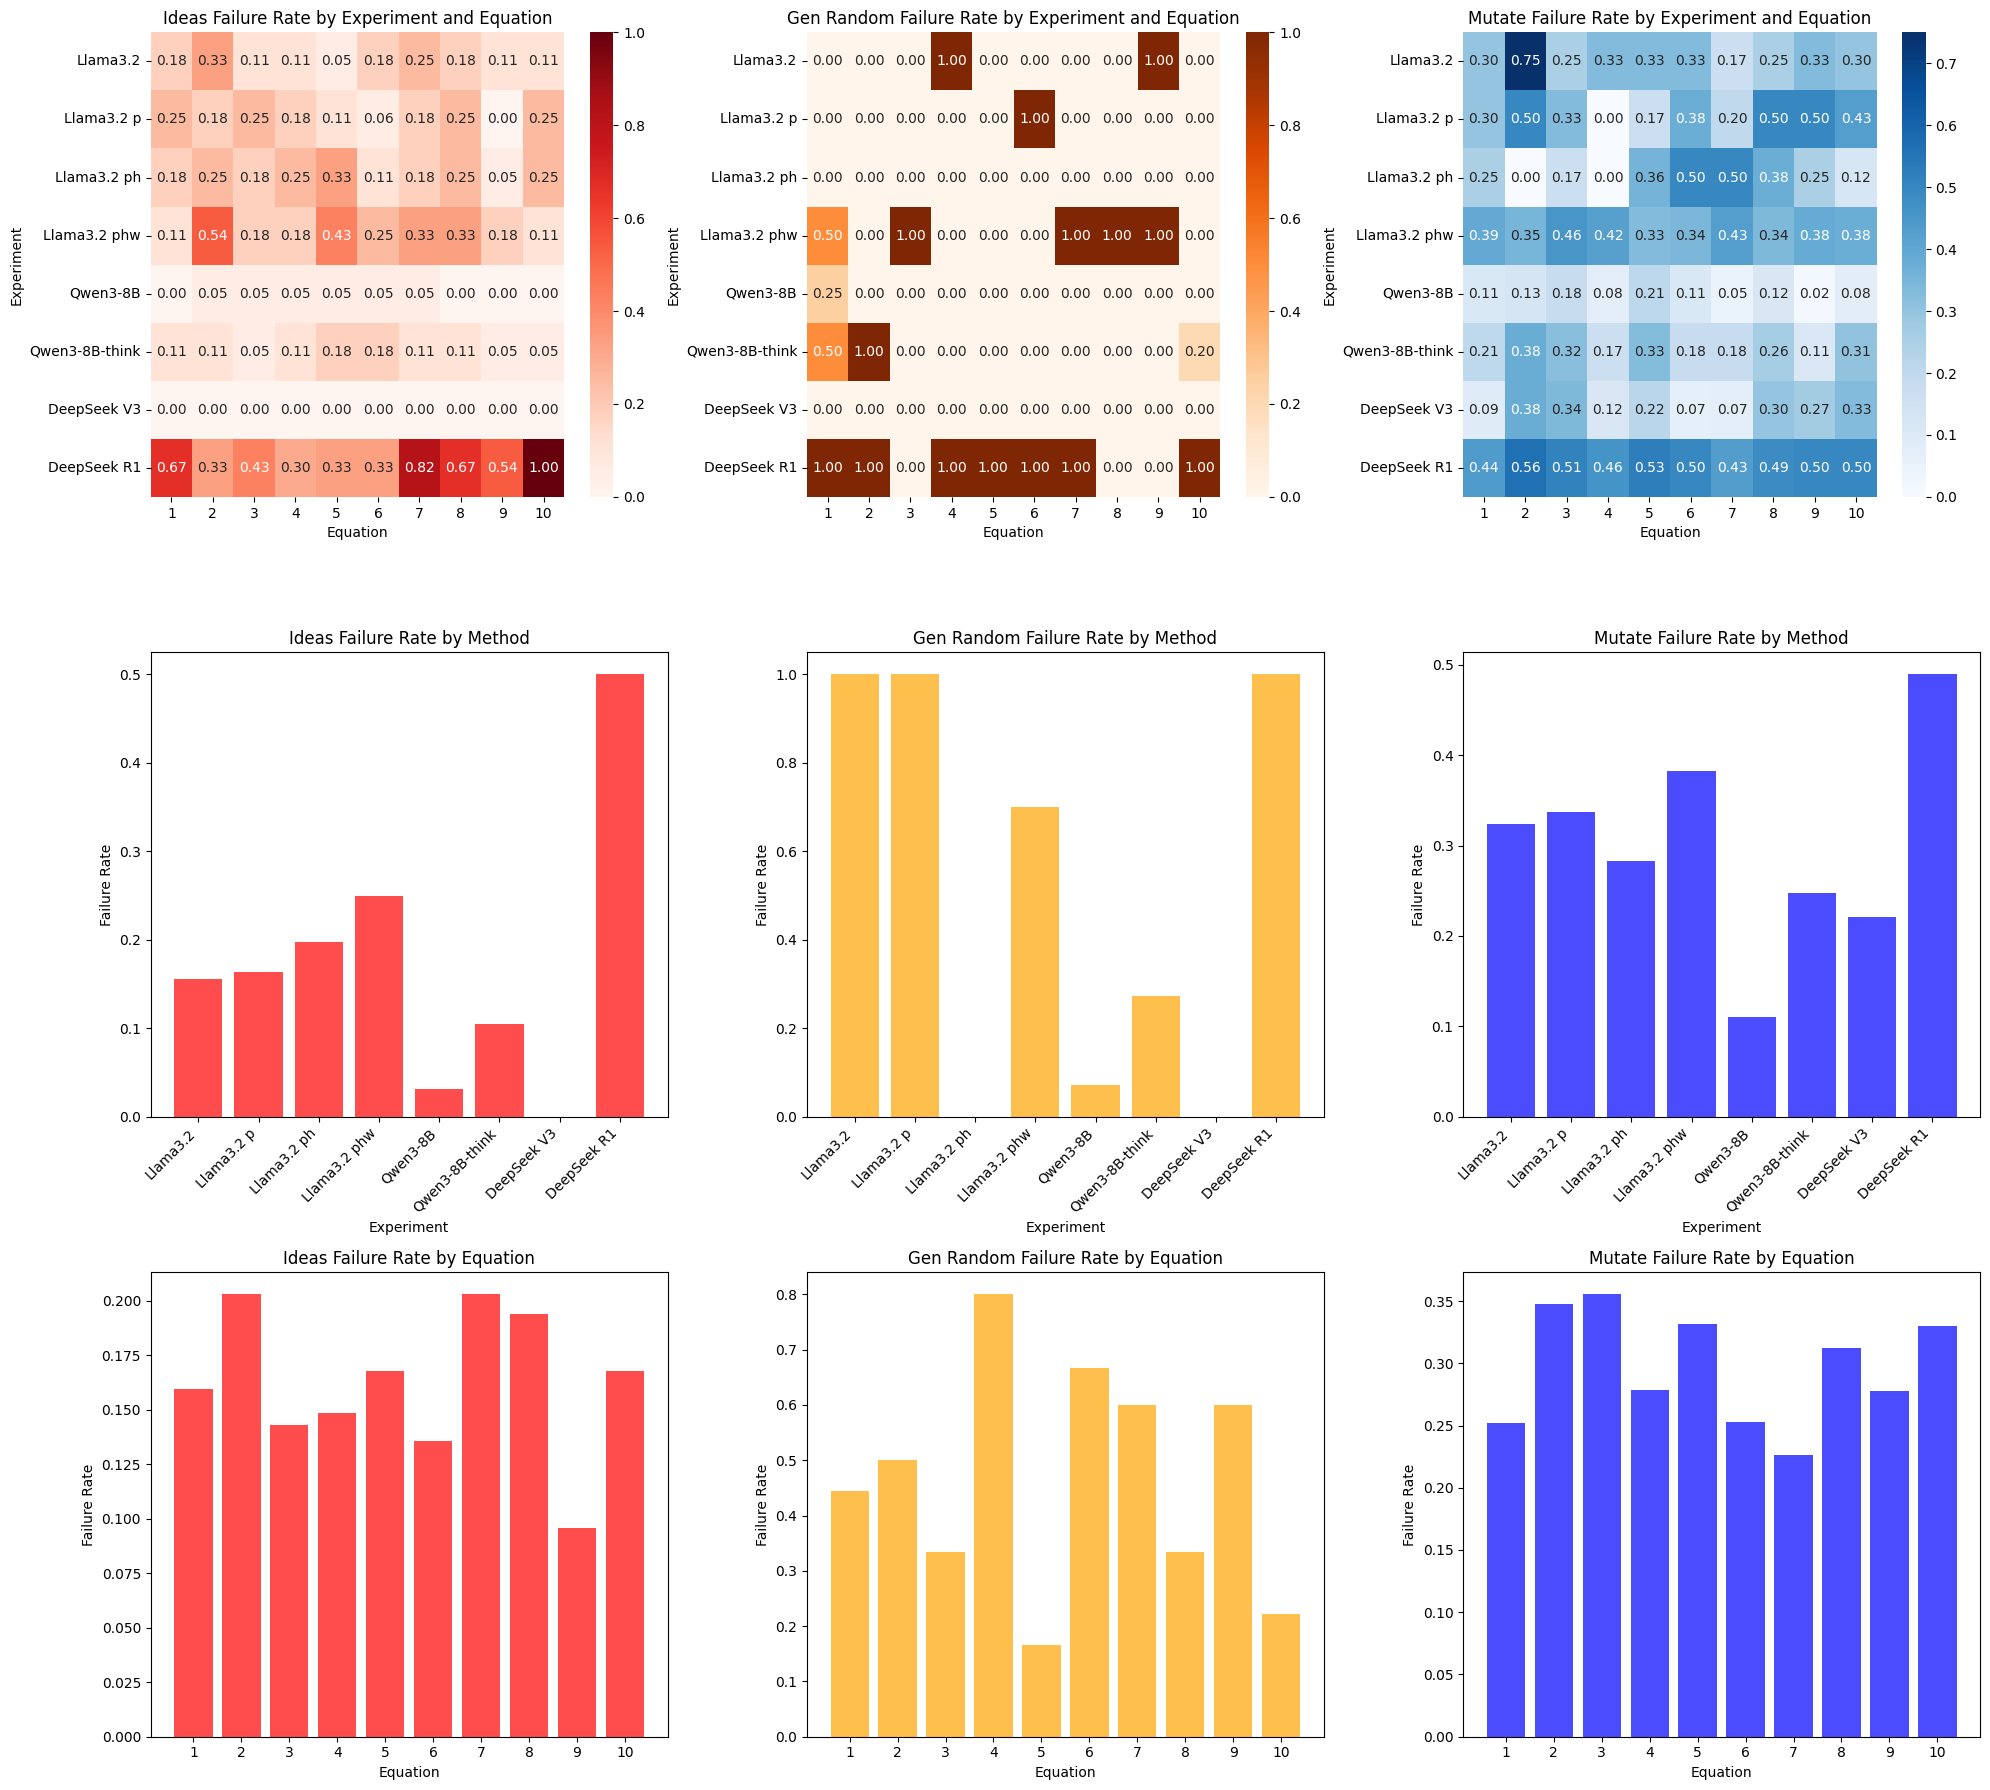

In [41]:
# Create comprehensive visualizations
fig, axes = plt.subplots(3, 3, figsize=(20, 18))

# Row 1: Heatmaps for each operation type
sns.heatmap(ideas_failure_rate_table, annot=True, fmt='.2f', cmap='Reds', ax=axes[0,0])
axes[0,0].set_title('Ideas Failure Rate by Experiment and Equation')
axes[0,0].set_xlabel('Equation')
axes[0,0].set_ylabel('Experiment')
axes[0,0].set_yticklabels([exp_labels[i] for i in range(8)], rotation=0)

sns.heatmap(gen_random_failure_rate_table, annot=True, fmt='.2f', cmap='Oranges', ax=axes[0,1])
axes[0,1].set_title('Gen Random Failure Rate by Experiment and Equation')
axes[0,1].set_xlabel('Equation')
axes[0,1].set_ylabel('Experiment')
axes[0,1].set_yticklabels([exp_labels[i] for i in range(8)], rotation=0)

sns.heatmap(mutate_failure_rate_table, annot=True, fmt='.2f', cmap='Blues', ax=axes[0,2])
axes[0,2].set_title('Mutate Failure Rate by Experiment and Equation')
axes[0,2].set_xlabel('Equation')
axes[0,2].set_ylabel('Experiment')
axes[0,2].set_yticklabels([exp_labels[i] for i in range(8)], rotation=0)

# Row 2: Bar plots by method for each operation type
method_labels = [exp_labels[i] for i in method_summary_ideas['experiment']]

axes[1,0].bar(range(len(method_summary_ideas)), method_summary_ideas['ideas_failure_rate'], color='red', alpha=0.7)
axes[1,0].set_title('Ideas Failure Rate by Method')
axes[1,0].set_xlabel('Experiment')
axes[1,0].set_ylabel('Failure Rate')
axes[1,0].set_xticks(range(len(method_summary_ideas)))
axes[1,0].set_xticklabels(method_labels, rotation=45, ha='right')

axes[1,1].bar(range(len(method_summary_gen_random)), method_summary_gen_random['gen_random_failure_rate'], color='orange', alpha=0.7)
axes[1,1].set_title('Gen Random Failure Rate by Method')
axes[1,1].set_xlabel('Experiment')
axes[1,1].set_ylabel('Failure Rate')
axes[1,1].set_xticks(range(len(method_summary_gen_random)))
axes[1,1].set_xticklabels(method_labels, rotation=45, ha='right')

axes[1,2].bar(range(len(method_summary_mutate)), method_summary_mutate['mutate_failure_rate'], color='blue', alpha=0.7)
axes[1,2].set_title('Mutate Failure Rate by Method')
axes[1,2].set_xlabel('Experiment')
axes[1,2].set_ylabel('Failure Rate')
axes[1,2].set_xticks(range(len(method_summary_mutate)))
axes[1,2].set_xticklabels(method_labels, rotation=45, ha='right')

# Row 3: Bar plots by equation for each operation type
axes[2,0].bar(equation_summary_ideas['equation'], equation_summary_ideas['ideas_failure_rate'], color='red', alpha=0.7)
axes[2,0].set_title('Ideas Failure Rate by Equation')
axes[2,0].set_xlabel('Equation')
axes[2,0].set_ylabel('Failure Rate')
axes[2,0].set_xticks(range(1, 11))

axes[2,1].bar(equation_summary_gen_random['equation'], equation_summary_gen_random['gen_random_failure_rate'], color='orange', alpha=0.7)
axes[2,1].set_title('Gen Random Failure Rate by Equation')
axes[2,1].set_xlabel('Equation')
axes[2,1].set_ylabel('Failure Rate')
axes[2,1].set_xticks(range(1, 11))

axes[2,2].bar(equation_summary_mutate['equation'], equation_summary_mutate['mutate_failure_rate'], color='blue', alpha=0.7)
axes[2,2].set_title('Mutate Failure Rate by Equation')
axes[2,2].set_xlabel('Equation')
axes[2,2].set_ylabel('Failure Rate')
axes[2,2].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

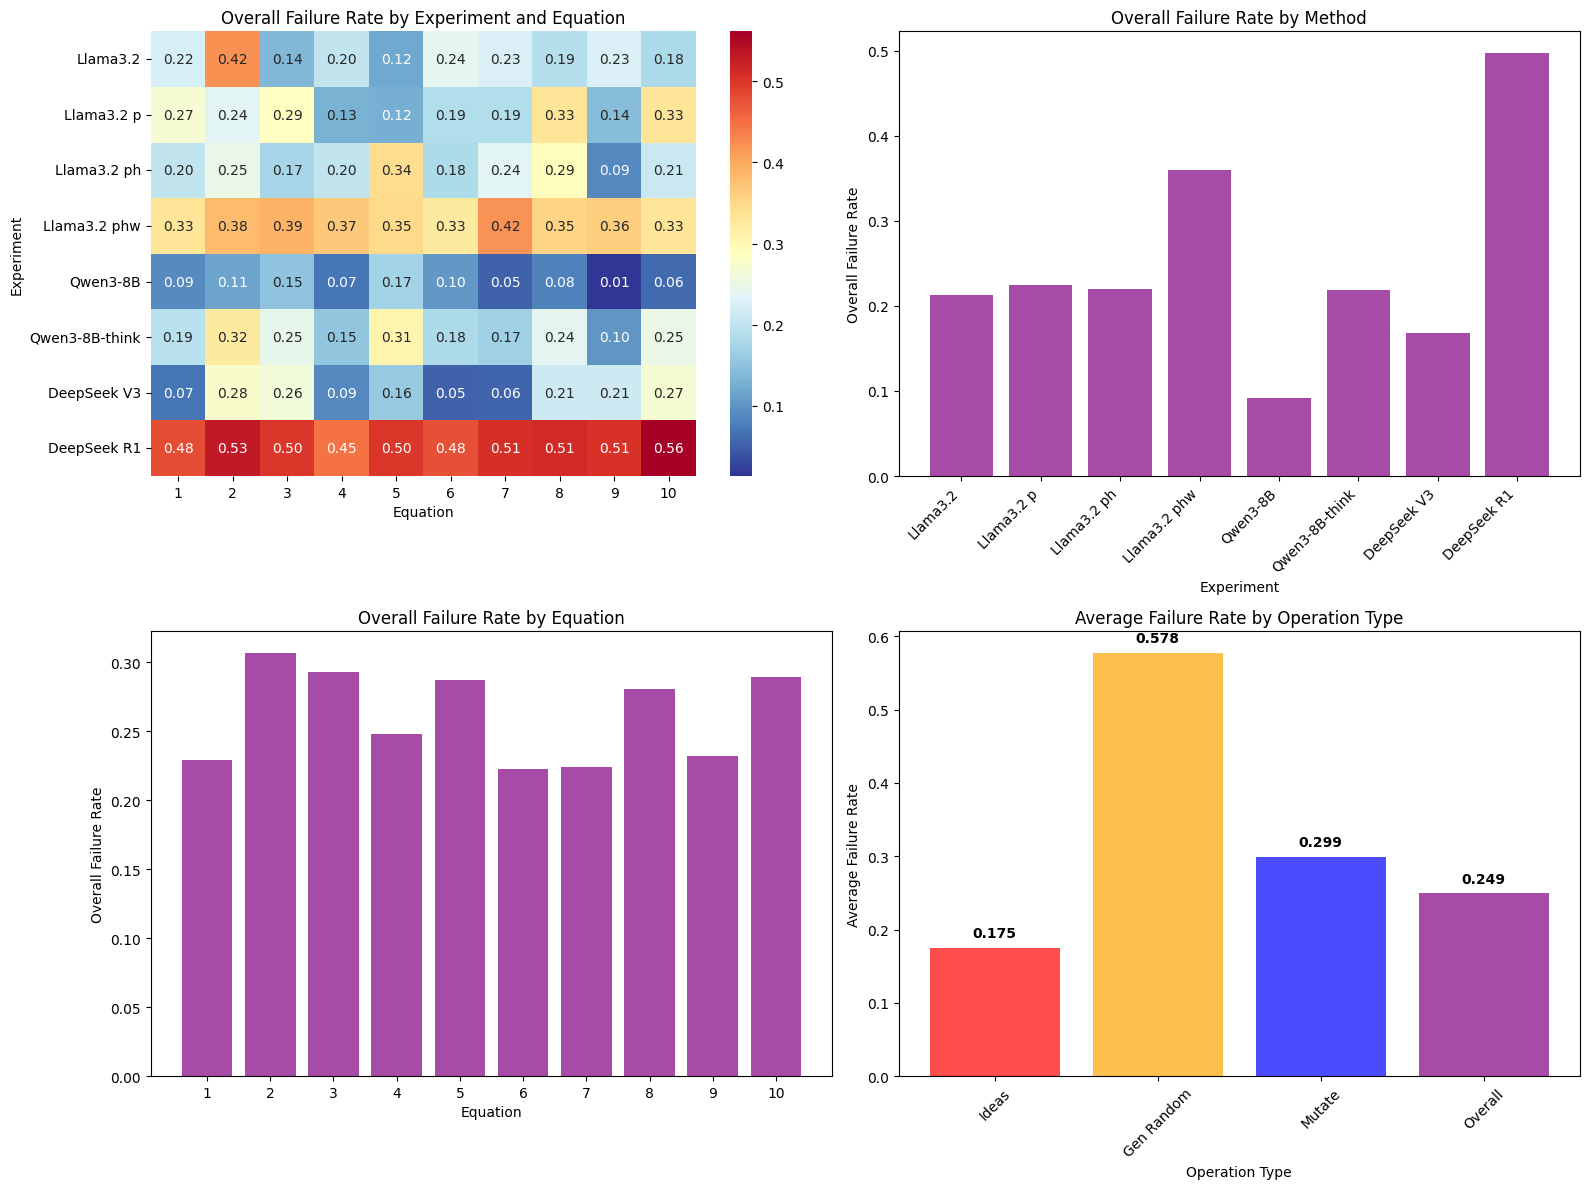

In [42]:
# Create overall summary heatmap and additional analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall failure rate heatmap
sns.heatmap(overall_failure_rate_table, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=axes[0,0])
axes[0,0].set_title('Overall Failure Rate by Experiment and Equation')
axes[0,0].set_xlabel('Equation')
axes[0,0].set_ylabel('Experiment')
axes[0,0].set_yticklabels([exp_labels[i] for i in range(8)], rotation=0)

# Overall failure rate by method
method_labels = [exp_labels[i] for i in method_summary_overall['experiment']]
axes[0,1].bar(range(len(method_summary_overall)), method_summary_overall['overall_failure_rate'], color='purple', alpha=0.7)
axes[0,1].set_title('Overall Failure Rate by Method')
axes[0,1].set_xlabel('Experiment')
axes[0,1].set_ylabel('Overall Failure Rate')
axes[0,1].set_xticks(range(len(method_summary_overall)))
axes[0,1].set_xticklabels(method_labels, rotation=45, ha='right')

# Overall failure rate by equation
axes[1,0].bar(equation_summary_overall['equation'], equation_summary_overall['overall_failure_rate'], color='purple', alpha=0.7)
axes[1,0].set_title('Overall Failure Rate by Equation')
axes[1,0].set_xlabel('Equation')
axes[1,0].set_ylabel('Overall Failure Rate')
axes[1,0].set_xticks(range(1, 11))

# Comparison of failure rates by operation type (aggregated)
operation_types = ['Ideas', 'Gen Random', 'Mutate', 'Overall']
avg_failure_rates = [
    method_summary_ideas['ideas_failure_rate'].mean(),
    method_summary_gen_random['gen_random_failure_rate'].mean(),
    method_summary_mutate['mutate_failure_rate'].mean(),
    method_summary_overall['overall_failure_rate'].mean()
]
colors = ['red', 'orange', 'blue', 'purple']

axes[1,1].bar(operation_types, avg_failure_rates, color=colors, alpha=0.7)
axes[1,1].set_title('Average Failure Rate by Operation Type')
axes[1,1].set_xlabel('Operation Type')
axes[1,1].set_ylabel('Average Failure Rate')
axes[1,1].tick_params(axis='x', rotation=45)

# Add values on bars
for i, (bar, rate) in enumerate(zip(axes[1,1].patches, avg_failure_rates)):
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{rate:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [43]:
# Comprehensive statistics summary
print("="*80)
print("COMPREHENSIVE LLM CALL FAILURE STATISTICS ANALYSIS")
print("="*80)

# Overall statistics across all operations
total_ideas = df['ideas_total'].sum()
total_gen_random = df['gen_random_total'].sum()
total_mutate = df['mutate_total'].sum()
total_all_operations = df['total_operations'].sum()

total_ideas_failed = df['ideas_failed'].sum()
total_gen_random_failed = df['gen_random_failed'].sum()
total_mutate_failed = df['mutate_failed'].sum()
total_all_failed = df['total_failures'].sum()

print(f"Overall Statistics Across All Experiments and Equations:")
print(f"  Ideas operations: {total_ideas:,} total, {total_ideas_failed:,} failed ({total_ideas_failed/total_ideas:.4f} failure rate)")
print(f"  Gen Random operations: {total_gen_random:,} total, {total_gen_random_failed:,} failed ({total_gen_random_failed/total_gen_random:.4f} failure rate)")
print(f"  Mutate operations: {total_mutate:,} total, {total_mutate_failed:,} failed ({total_mutate_failed/total_mutate:.4f} failure rate)")
print(f"  ALL operations: {total_all_operations:,} total, {total_all_failed:,} failed ({total_all_failed/total_all_operations:.4f} failure rate)")

print(f"\nOperation Type Breakdown:")
print(f"  Ideas: {total_ideas/total_all_operations:.1%} of all operations")
print(f"  Gen Random: {total_gen_random/total_all_operations:.1%} of all operations")
print(f"  Mutate: {total_mutate/total_all_operations:.1%} of all operations")

print(f"\nFailure Distribution:")
print(f"  Ideas failures: {total_ideas_failed/total_all_failed:.1%} of all failures")
print(f"  Gen Random failures: {total_gen_random_failed/total_all_failed:.1%} of all failures")
print(f"  Mutate failures: {total_mutate_failed/total_all_failed:.1%} of all failures")

# Best and worst performing experiments by operation type
print(f"\n" + "="*80)
print("BEST AND WORST PERFORMING EXPERIMENTS BY OPERATION TYPE")
print("="*80)

for op_type, summary_df, rate_col in [
    ('Ideas', method_summary_ideas, 'ideas_failure_rate'),
    ('Gen Random', method_summary_gen_random, 'gen_random_failure_rate'),
    ('Mutate', method_summary_mutate, 'mutate_failure_rate'),
    ('Overall', method_summary_overall, 'overall_failure_rate')
]:
    print(f"\n{op_type} Operation:")
    
    # Filter out experiments with zero operations
    valid_summary = summary_df[summary_df[rate_col].notna() & (summary_df[rate_col] >= 0)]
    
    if len(valid_summary) > 0:
        best_idx = valid_summary[rate_col].idxmin()
        worst_idx = valid_summary[rate_col].idxmax()
        
        best_exp = valid_summary.loc[best_idx, 'experiment']
        worst_exp = valid_summary.loc[worst_idx, 'experiment']
        best_rate = valid_summary.loc[best_idx, rate_col]
        worst_rate = valid_summary.loc[worst_idx, rate_col]
        
        print(f"  Best: {exp_labels[best_exp]} (failure rate: {best_rate:.4f})")
        print(f"  Worst: {exp_labels[worst_exp]} (failure rate: {worst_rate:.4f})")
        print(f"  Ratio (worst/best): {worst_rate/best_rate:.2f}x" if best_rate > 0 else "  Ratio: N/A (best has 0 failures)")

# Most problematic equations
print(f"\n" + "="*80)
print("MOST PROBLEMATIC EQUATIONS BY OPERATION TYPE")
print("="*80)

for op_type, summary_df, rate_col in [
    ('Ideas', equation_summary_ideas, 'ideas_failure_rate'),
    ('Gen Random', equation_summary_gen_random, 'gen_random_failure_rate'),
    ('Mutate', equation_summary_mutate, 'mutate_failure_rate'),
    ('Overall', equation_summary_overall, 'overall_failure_rate')
]:
    print(f"\n{op_type} Operation:")
    
    # Filter out equations with zero operations
    valid_summary = summary_df[summary_df[rate_col].notna() & (summary_df[rate_col] >= 0)]
    
    if len(valid_summary) > 0:
        # Sort by failure rate (worst first)
        sorted_summary = valid_summary.sort_values(rate_col, ascending=False)
        
        print(f"  Top 3 most problematic equations:")
        for i, (_, row) in enumerate(sorted_summary.head(3).iterrows()):
            eq_num = int(row['equation'])
            rate = row[rate_col]
            print(f"    {i+1}. Equation {eq_num}: {rate:.4f} failure rate")
        
        print(f"  Top 3 best performing equations:")
        for i, (_, row) in enumerate(sorted_summary.tail(3).iterrows()):
            eq_num = int(row['equation'])
            rate = row[rate_col]
            print(f"    {i+1}. Equation {eq_num}: {rate:.4f} failure rate")

# Operation correlation analysis
print(f"\n" + "="*80)
print("OPERATION TYPE CORRELATION ANALYSIS")
print("="*80)

correlation_df = df[['ideas_failure_rate', 'gen_random_failure_rate', 'mutate_failure_rate', 'overall_failure_rate']].corr()
print("Failure Rate Correlations:")
print(correlation_df.round(4))

print(f"\nKey Insights:")
if correlation_df.loc['ideas_failure_rate', 'mutate_failure_rate'] > 0.5:
    print(f"  - Strong positive correlation between Ideas and Mutate failure rates ({correlation_df.loc['ideas_failure_rate', 'mutate_failure_rate']:.3f})")
elif correlation_df.loc['ideas_failure_rate', 'mutate_failure_rate'] < -0.5:
    print(f"  - Strong negative correlation between Ideas and Mutate failure rates ({correlation_df.loc['ideas_failure_rate', 'mutate_failure_rate']:.3f})")
else:
    print(f"  - Moderate correlation between Ideas and Mutate failure rates ({correlation_df.loc['ideas_failure_rate', 'mutate_failure_rate']:.3f})")

if correlation_df.loc['gen_random_failure_rate', 'mutate_failure_rate'] > 0.5:
    print(f"  - Strong positive correlation between Gen Random and Mutate failure rates ({correlation_df.loc['gen_random_failure_rate', 'mutate_failure_rate']:.3f})")
elif correlation_df.loc['gen_random_failure_rate', 'mutate_failure_rate'] < -0.5:
    print(f"  - Strong negative correlation between Gen Random and Mutate failure rates ({correlation_df.loc['gen_random_failure_rate', 'mutate_failure_rate']:.3f})")
else:
    print(f"  - Moderate correlation between Gen Random and Mutate failure rates ({correlation_df.loc['gen_random_failure_rate', 'mutate_failure_rate']:.3f})")

print("="*80)

COMPREHENSIVE LLM CALL FAILURE STATISTICS ANALYSIS
Overall Statistics Across All Experiments and Equations:
  Ideas operations: 1,386 total, 223 failed (0.1609 failure rate)
  Gen Random operations: 59 total, 26 failed (0.4407 failure rate)
  Mutate operations: 3,635 total, 1,076 failed (0.2960 failure rate)
  ALL operations: 5,080 total, 1,325 failed (0.2608 failure rate)

Operation Type Breakdown:
  Ideas: 27.3% of all operations
  Gen Random: 1.2% of all operations
  Mutate: 71.6% of all operations

Failure Distribution:
  Ideas failures: 16.8% of all failures
  Gen Random failures: 2.0% of all failures
  Mutate failures: 81.2% of all failures

BEST AND WORST PERFORMING EXPERIMENTS BY OPERATION TYPE

Ideas Operation:
  Best: DeepSeek V3 (failure rate: 0.0000)
  Worst: DeepSeek R1 (failure rate: 0.5000)
  Ratio: N/A (best has 0 failures)

Gen Random Operation:
  Best: DeepSeek V3 (failure rate: 0.0000)
  Worst: Llama3.2 (failure rate: 1.0000)
  Ratio: N/A (best has 0 failures)

Mutat